In [1]:
## Standard libraries
import os
import math
import numpy as np
import time

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgba
import seaborn as sns
sns.set()

## Progress bar
from tqdm.auto import tqdm

In [2]:
import jax
import jax.numpy as jnp

print(jax.__version__)

0.8.0


# Implementing a Neural Network

In [3]:
import flax
from flax import linen as nn
import jax.numpy as jnp
import jax

In [4]:
TRAIN_DATASET_SIZE = 2400
VAL_DATASET_SIZE   = 400
BATCH_SIZE         = 8
EPOCHS             = 10

### Model Definition

In [5]:
class SimpleNet(nn.Module):
    n_hidden: int
    n_out: int
    dtype: jnp.dtype
    
    @nn.compact
    def __call__(self, x):
        x = nn.Dense(features=self.n_hidden, dtype=self.dtype)(x)
        x = nn.tanh(x)
        x = nn.Dense(features=self.n_out, dtype=self.dtype)(x)
        return x

In [6]:
rng = jax.random.PRNGKey(42)
rng, inp_rng, init_rng = jax.random.split(rng, 3)
model = SimpleNet(8,1,jnp.bfloat16)
inp = jax.random.normal(inp_rng, (8, 2))  # Batch size 8, input size 2

# Initialize the model
params = model.init(init_rng, inp)
print(params)

{'params': {'Dense_0': {'kernel': Array([[ 0.00546537,  0.8213236 ,  1.0780088 , -0.7214763 , -0.09285586,
         0.5358961 , -0.81994814,  0.43951333],
       [-0.22837543,  0.9373552 ,  0.7489871 , -0.45520955,  0.61383283,
        -0.91844344, -0.03173327, -1.2298081 ]], dtype=float32), 'bias': Array([0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)}, 'Dense_1': {'kernel': Array([[-0.08419465],
       [-0.17733364],
       [ 0.37821612],
       [-0.24959026],
       [-0.15340449],
       [-0.3345969 ],
       [ 0.69997376],
       [-0.31296203]], dtype=float32), 'bias': Array([0.], dtype=float32)}}}


### Dataloader Definition

In [7]:
from dataloader import XORDataset

dataset = XORDataset(size=200, seed=42)
print(type(dataset[0:2]))
print(f"Dataset size: {len(dataset)}")
print(f"Sample 0: {dataset[0]}")

<class 'tuple'>
Dataset size: 200
Sample 0: (array([-0.06800247,  1.0232254 ], dtype=float32), np.int32(1))


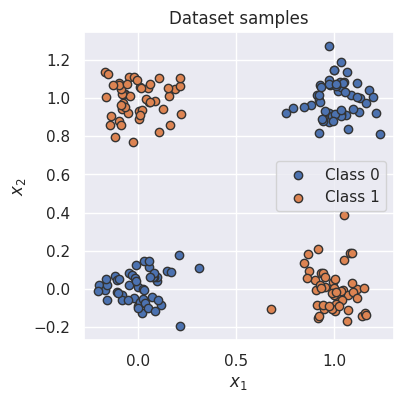

In [8]:
import matplotlib.pyplot as plt

def visualize_samples(data, label):
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    plt.figure(figsize=(4,4))
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

visualize_samples(dataset.data, dataset.label)
plt.show()

In [9]:
from grain.python import (
    DataLoader, 
    IndexSampler,
    ShardOptions
)   
from grain.transforms import Batch
DRP_RMN = True

# Define Sampler
index_sampler = IndexSampler(
    num_records=len(dataset),
    num_epochs=EPOCHS,
    shard_options=ShardOptions(
        shard_index=0, 
        shard_count=1, 
        drop_remainder=DRP_RMN
    ),
    shuffle=True,
    seed=0
)

# Define Dataloader
dataloader = DataLoader(
    data_source=dataset,
    operations=[Batch(batch_size=BATCH_SIZE, drop_remainder=DRP_RMN)],
    sampler=index_sampler,
    worker_count=0
)

data_inputs, data_labels = next(iter(dataloader))
print("Data inputs", data_inputs.shape, "\n", data_inputs)
print("Data labels", data_labels.shape, "\n", data_labels)

Data inputs (8, 2) 
 [[ 0.20607479  0.17553408]
 [ 1.1179297   1.0067519 ]
 [ 0.99228984  0.0341152 ]
 [ 1.0645376   1.1368631 ]
 [-0.00626791  1.0955142 ]
 [-0.02081222 -0.04930009]
 [ 0.02449666 -0.05069432]
 [ 0.91104853 -0.08158103]]
Data labels (8,) 
 [0 0 1 0 1 0 0 1]


### Optimization

In [10]:
import optax

LR = 0.1
optimizer = optax.sgd(learning_rate=LR)

In [11]:
from flax.training.train_state import TrainState

model_state = TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=optimizer
)

def bin_cross_ent(state, params, batch):
    data, labels = batch
    logits = state.apply_fn(params, data).squeeze(axis=-1)
    pred = (logits > 0).astype(jnp.float32)
    loss = optax.sigmoid_binary_cross_entropy(logits, labels).mean()
    acc = (pred == labels).mean()
    return loss, acc

In [12]:
@jax.jit
def train_step(state, batch):
    grad = jax.value_and_grad(
        bin_cross_ent,
        argnums=1,
        has_aux=True
    )
    (loss, acc), grads = grad(state, state.params, batch)
    state = state.apply_gradients(grads=grads)
    return state, loss, acc

@jax.jit
def val_step(state, batch):
    _, acc = bin_cross_ent(state, state.params, batch)
    return acc

In [13]:
import orbax.checkpoint as ocp
from pathlib import Path
import os

OUTPUT = Path(f"{os.environ['PWD']}/checkpoints")
OUTPUT.mkdir(exist_ok=True)

ckpt_dir = ocp.test_utils.erase_and_create_empty(OUTPUT)
checkpointer = ocp.StandardCheckpointer()

In [14]:
CKPT_EVERY = 2

def train(state, dataloader):
    for epoch in tqdm(range(EPOCHS)):
        for batch in dataloader:
            state, loss, acc = train_step(state, batch)
        print(f"Epoch {epoch+1} - Loss: {loss}, Accuracy: {acc}")
        if not (epoch+1 % CKPT_EVERY):
            checkpointer.save(OUTPUT / f'state_{epoch+1}.ckpt', state)            
    return state

In [15]:
train_dataset = XORDataset(TRAIN_DATASET_SIZE, 42)
val_dataset   = XORDataset(VAL_DATASET_SIZE, 24)

train_dataloader = DataLoader(
    data_source=train_dataset,
    operations=[Batch(batch_size=BATCH_SIZE, drop_remainder=DRP_RMN)],
    sampler=index_sampler,
    worker_count=0
)

val_dataloader = DataLoader(
    data_source=val_dataset,
    operations=[Batch(batch_size=BATCH_SIZE, drop_remainder=DRP_RMN)],
    sampler=index_sampler,
    worker_count=0
)

In [20]:
model_trained_state = train(model_state, train_dataloader)
trained_model = model.bind(model_trained_state.params)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 - Loss: 0.369141, Accuracy: 1.0
Epoch 2 - Loss: 0.135742, Accuracy: 1.0
Epoch 3 - Loss: 0.0649414, Accuracy: 1.0
Epoch 4 - Loss: 0.0410156, Accuracy: 1.0
Epoch 5 - Loss: 0.029541, Accuracy: 1.0
Epoch 6 - Loss: 0.0220947, Accuracy: 1.0
Epoch 7 - Loss: 0.0179443, Accuracy: 1.0
Epoch 8 - Loss: 0.0153198, Accuracy: 1.0
Epoch 9 - Loss: 0.0126953, Accuracy: 1.0
Epoch 10 - Loss: 0.0111694, Accuracy: 1.0


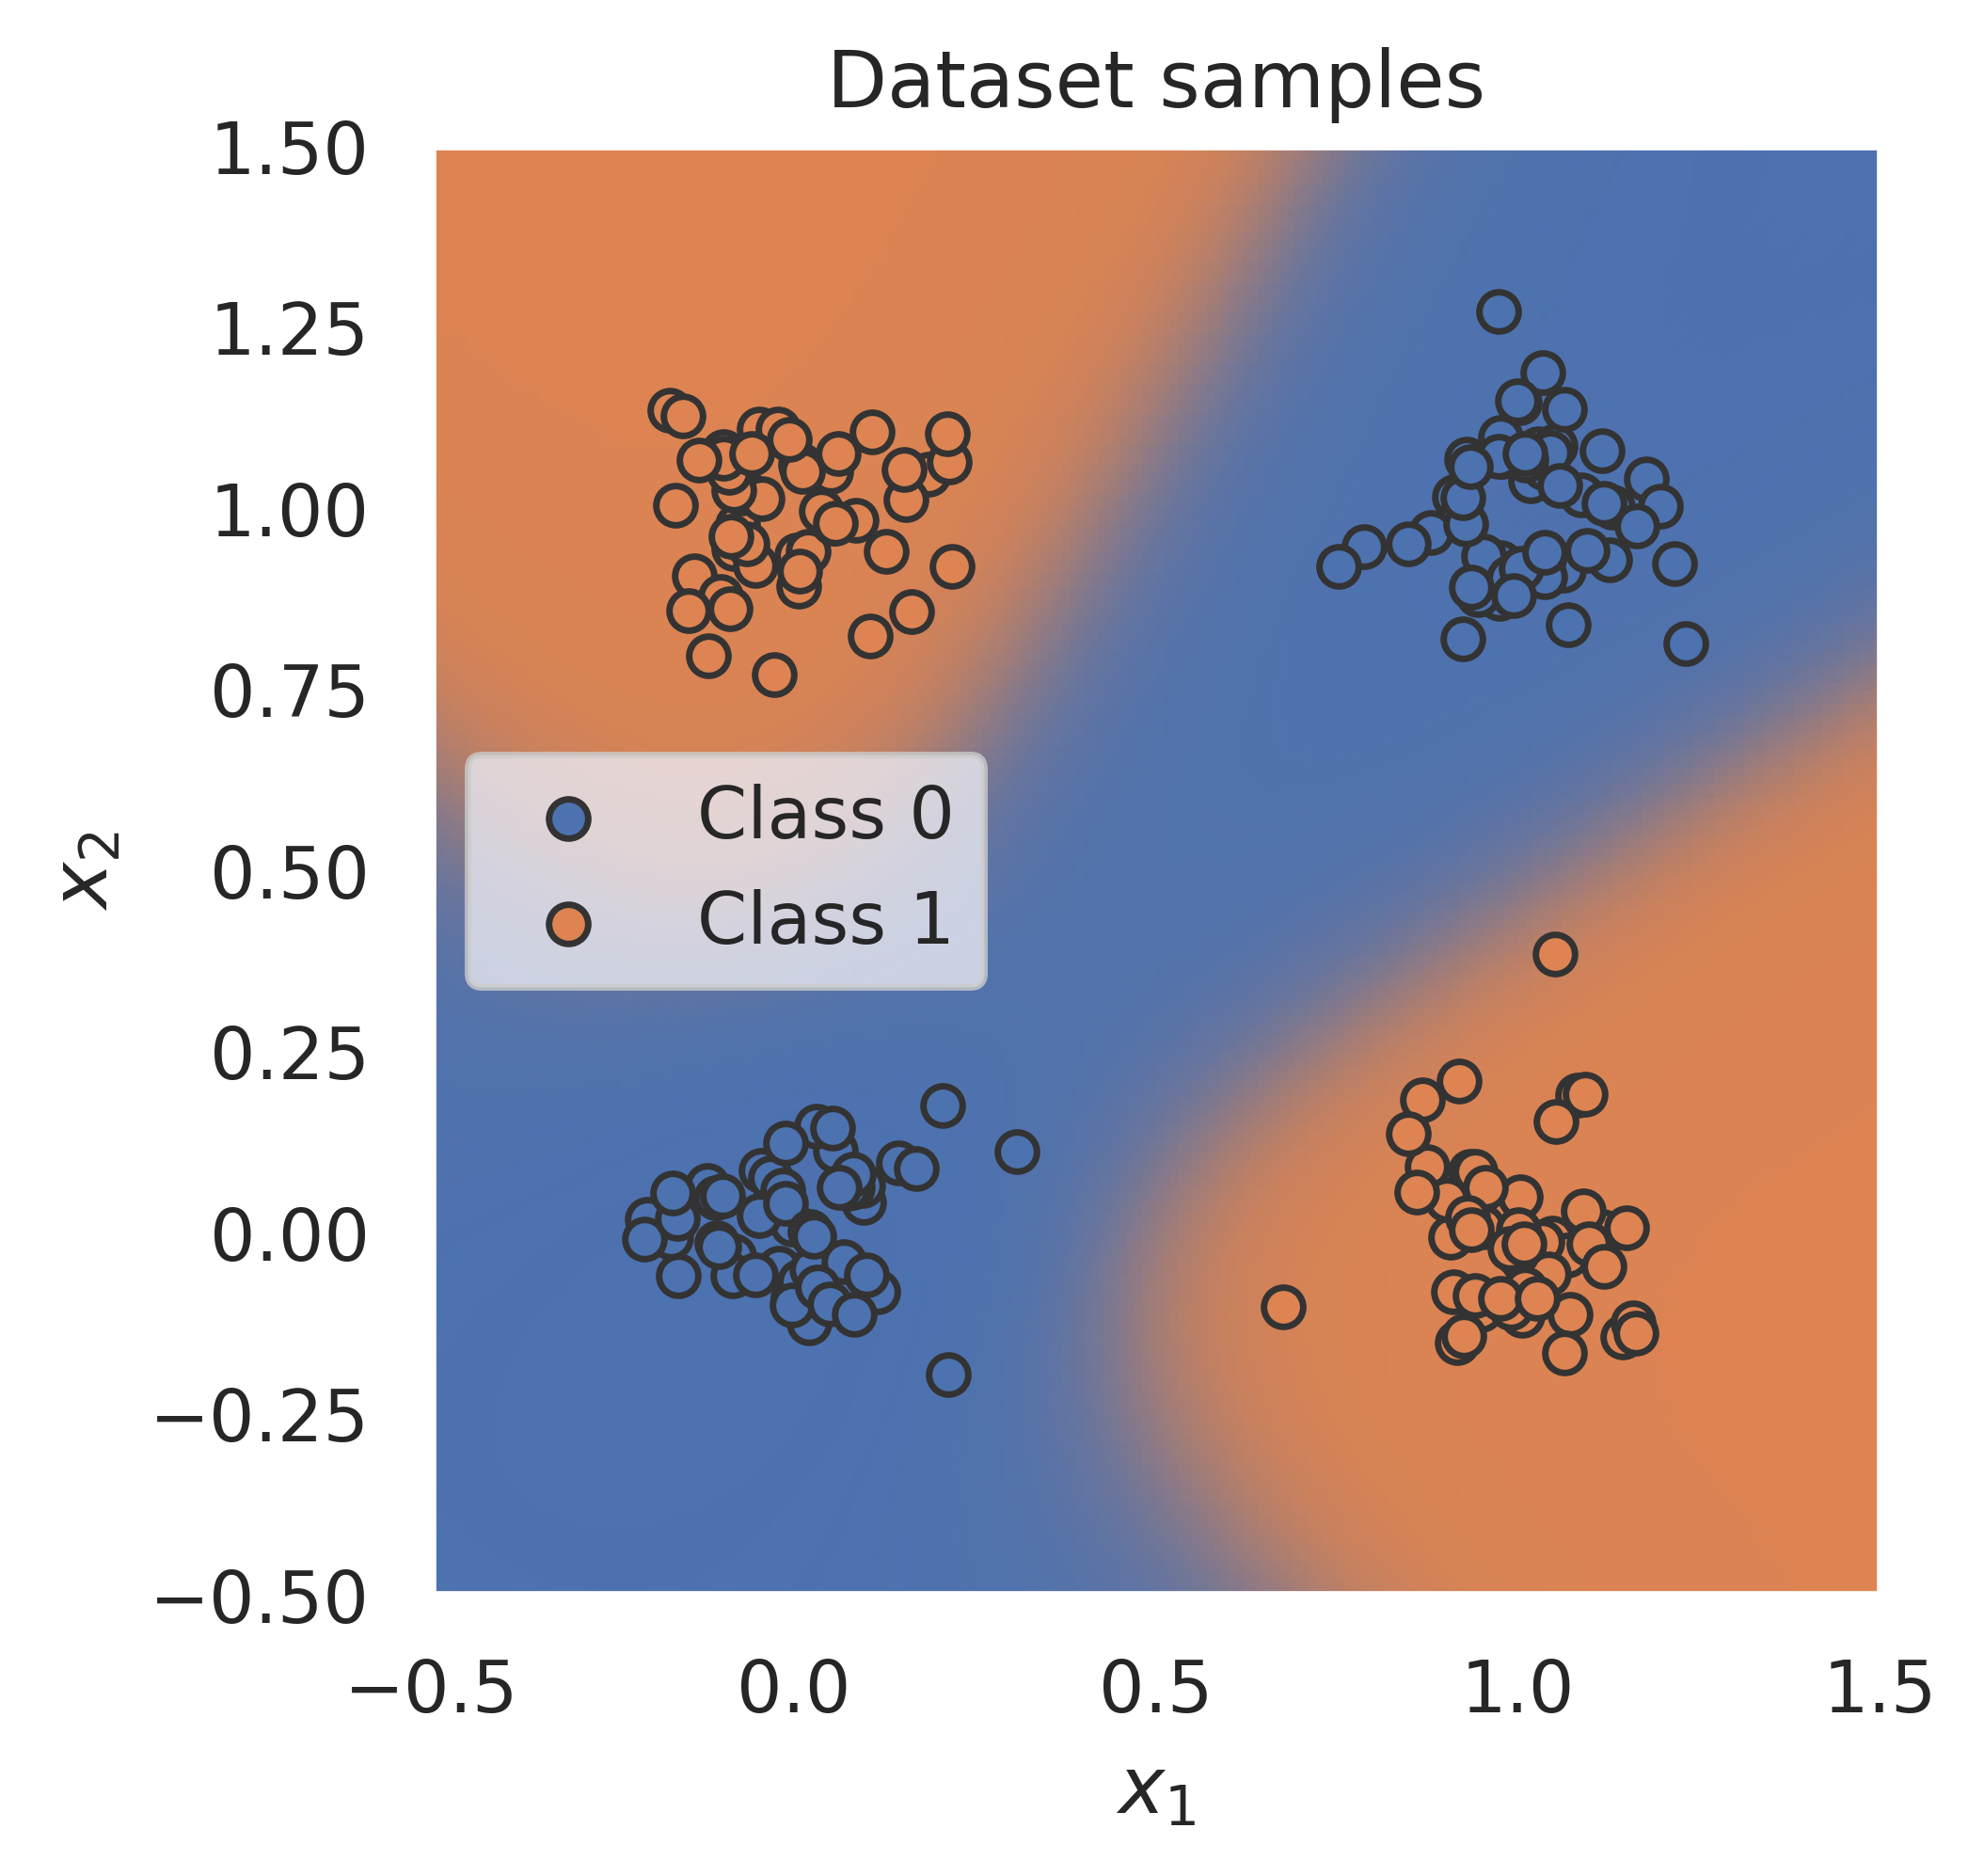

In [21]:
def visualize_classification(model, data, label):
    data_0 = data[label == 0]
    data_1 = data[label == 1]

    fig = plt.figure(figsize=(4,4), dpi=500)
    plt.scatter(data_0[:,0], data_0[:,1], edgecolor="#333", label="Class 0")
    plt.scatter(data_1[:,0], data_1[:,1], edgecolor="#333", label="Class 1")
    plt.title("Dataset samples")
    plt.ylabel(r"$x_2$")
    plt.xlabel(r"$x_1$")
    plt.legend()

    # Let's make use of a lot of operations we have learned above
    c0 = np.array(to_rgba("C0"))
    c1 = np.array(to_rgba("C1"))
    x1 = jnp.arange(-0.5, 1.5, step=0.01)
    x2 = jnp.arange(-0.5, 1.5, step=0.01)
    xx1, xx2 = jnp.meshgrid(x1, x2, indexing='ij')  # Meshgrid function as in numpy
    model_inputs = np.stack([xx1, xx2], axis=-1)
    logits = model(model_inputs)
    preds = nn.sigmoid(logits)
    output_image = (1 - preds) * c0[None,None] + preds * c1[None,None]  # Specifying "None" in a dimension creates a new one
    output_image = jax.device_get(output_image)  # Convert to numpy array. This only works for tensors on CPU, hence first push to CPU
    plt.imshow(output_image, origin='lower', extent=(-0.5, 1.5, -0.5, 1.5))
    plt.grid(False)
    return fig

_ = visualize_classification(trained_model, dataset.data, dataset.label)
plt.show()